# 🧠 Anomaly Detection — Sales by Product Category (Mapped Names)

This notebook detects anomalies **within logical product groups (Product Category Mapped)**
based only on sales values. Temperature, region, and other contextual features are ignored.
Each mapped product category is analyzed separately using IsolationForest.

It produces category-specific models compatible with `ReportGenerator`.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import IsolationForest
import joblib
from app.file_process.report_generator import DataProcessor,CATEGORY_MAPPING

In [29]:
# --- 1. Load all CSVs ---
DATA_DIR = Path('../data/Sabores Ibéricos Company Transaction Data')
PATTERN = 'sales_*.csv'
csv_paths = sorted(DATA_DIR.glob(PATTERN))
if not csv_paths:
    raise FileNotFoundError(f'No CSV files matching {PATTERN} in {DATA_DIR}')
df_list = []
for path in csv_paths:
    temp_df = pd.read_csv(path)
    temp_df['source_file'] = path.name
    df_list.append(temp_df)
df = pd.concat(df_list, ignore_index=True)
print(f'✅ Loaded {len(df)} rows from {len(df_list)} files.')

✅ Loaded 1653 rows from 29 files.


In [30]:
# --- 2. Apply category mapping (for consistency with ReportGenerator) ---
df = DataProcessor.map_categories(df)
if 'Product Category Mapped' not in df.columns:
    raise ValueError("Mapping failed — column 'Product Category Mapped' not found.")
df.head()

,Date,Region,Product,Product Category,Temperature,DayOfWeek,Sales,source_file,Product Category Mapped
0,2025-02-01,North,Coca-Cola,AA,10.7,Saturday,1172,sales_2025-02-01.csv,Carbonated Drink
1,2025-02-01,North,Fanta,AA,10.7,Saturday,1122,sales_2025-02-01.csv,Carbonated Drink
2,2025-02-01,North,Sprite,AA,10.7,Saturday,997,sales_2025-02-01.csv,Carbonated Drink
3,2025-02-01,North,Pepsi,AA,10.7,Saturday,1061,sales_2025-02-01.csv,Carbonated Drink
4,2025-02-01,North,Golden Milk,AB,10.7,Saturday,1165,sales_2025-02-01.csv,Plant-Based Drink


In [31]:
# --- 3. Detect anomalies per mapped category ---
df['is_anomaly'] = 0
models = {}
for cat, group in df.groupby('Product Category Mapped'):
    if len(group) < 5:
        print(f"⚠️ Skipping category '{cat}' — not enough samples ({len(group)} rows).")
        continue
    model = IsolationForest(contamination=0.05, random_state=42)
    preds = model.fit_predict(group[['Sales']])
    df.loc[group.index, 'is_anomaly'] = (preds == -1).astype(int)
    models[cat] = model
    print(f"✅ {cat:25s} — {(preds == -1).sum()} anomalies ({100*(preds == -1).mean():.2f}%)")
print(f"\n✅ Global: {df['is_anomaly'].sum()} anomalies ({100*df['is_anomaly'].mean():.2f}%) detected.")

✅ Carbonated Drink          — 18 anomalies (5.17%)
✅ Diet Drink                — 13 anomalies (4.98%)
✅ Fruit Juice               — 13 anomalies (4.98%)
✅ Functional Beverage       — 13 anomalies (4.98%)
✅ Milkshake                 — 13 anomalies (4.98%)
✅ Plant-Based Drink         — 13 anomalies (4.98%)

✅ Global: 83 anomalies (5.02%) detected.


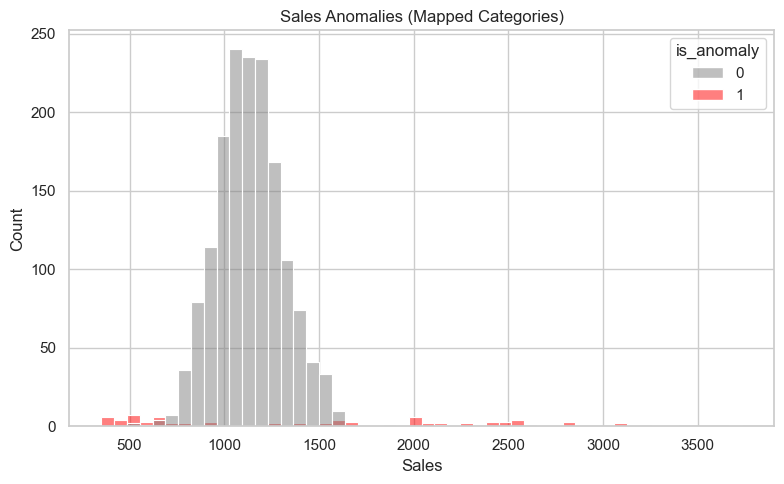

In [32]:
# --- 4. Visualize global sales anomalies ---
sns.set(style='whitegrid')
plt.figure(figsize=(8,5))
sns.histplot(df, x='Sales', hue='is_anomaly', bins=50, palette={0:'gray', 1:'red'})
plt.title('Sales Anomalies (Mapped Categories)')
plt.tight_layout()
plt.show()

C:\Users\ppiotrowska\AppData\Local\Temp\ipykernel_8980\771143411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anom_summary.index, y=anom_summary.values, palette='coolwarm')


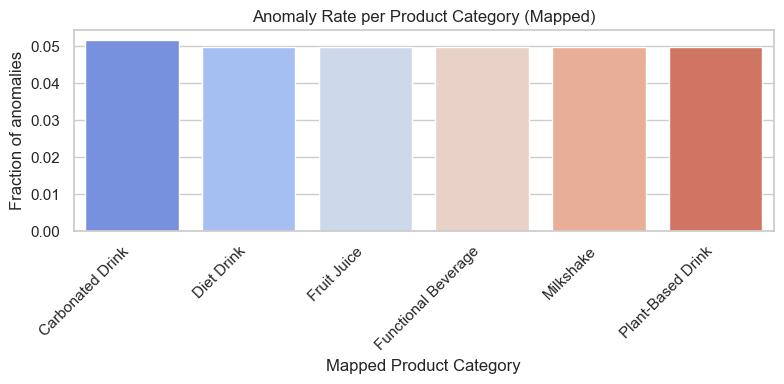

In [33]:
# --- 5. Anomaly rate per mapped category ---
anom_summary = df.groupby('Product Category Mapped')['is_anomaly'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=anom_summary.index, y=anom_summary.values, palette='coolwarm')
plt.title('Anomaly Rate per Product Category (Mapped)')
plt.ylabel('Fraction of anomalies')
plt.xlabel('Mapped Product Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

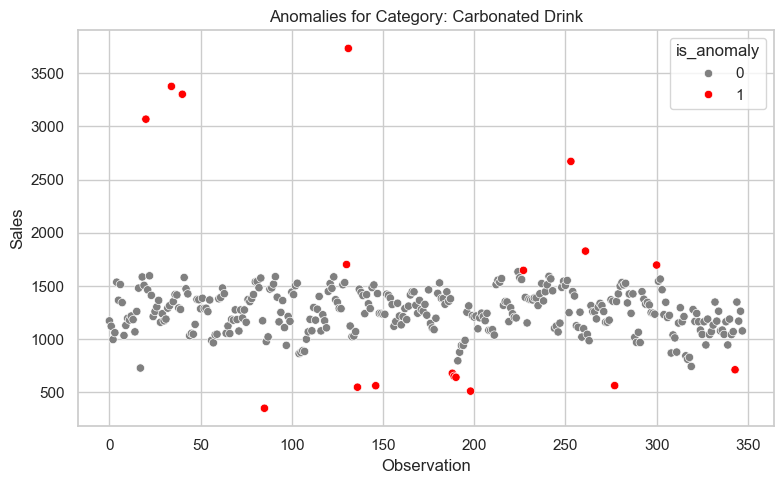

In [34]:
# --- 6. Example: anomalies in one mapped category ---
example_cat = anom_summary.index[0]
subset = df[df['Product Category Mapped'] == example_cat]
plt.figure(figsize=(8,5))
sns.scatterplot(data=subset, x=range(len(subset)), y='Sales', hue='is_anomaly', palette={0:'gray', 1:'red'})
plt.title(f'Anomalies for Category: {example_cat}')
plt.xlabel('Observation')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

In [35]:
# --- 7. Save models and annotated data ---
MODEL_PATH = Path('../models/category_anomaly_models.pkl')
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(models, MODEL_PATH)
print(f'💾 Saved {len(models)} category-specific models to: {MODEL_PATH}')
OUTPUT_PATH = Path('../data/sales_with_category_anomalies.csv')
df.to_csv(OUTPUT_PATH, index=False)
print(f'💾 Data with anomalies saved to: {OUTPUT_PATH}')

💾 Saved 6 category-specific models to: ..\models\category_anomaly_models.pkl
💾 Data with anomalies saved to: ..\data\sales_with_category_anomalies.csv


In [ ]:
# --- 8. Preview detected anomalies ---
df[df['is_anomaly'] == 1].sample(min(10, df['is_anomaly'].sum()), random_state=42)